In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from spectraderm.spectral.visualization import (
    HYPERSKIN_VIS_WAVELENGTHS,
    spectral_to_false_color,
    get_band,
    extract_region_spectrum,
)

print("Module K — Spectral Visualization")
print(f"Wavelengths: {HYPERSKIN_VIS_WAVELENGTHS[0]}–{HYPERSKIN_VIS_WAVELENGTHS[-1]} nm")
print(f"Number of reconstructed bands: {len(HYPERSKIN_VIS_WAVELENGTHS)}")

Module K — Spectral Visualization
Wavelengths: 400–700 nm
Number of reconstructed bands: 31


In [2]:
from pathlib import Path
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent

cube_path = PROJECT_ROOT / "data" / "interim" / "face_spectral_cube.npy"

face_spectral_cube = np.load(cube_path)

print("Loaded spectral cube")
print("Shape:", face_spectral_cube.shape)
print("Dtype:", face_spectral_cube.dtype)
print(
    "Range:",
    float(face_spectral_cube.min()),
    "to",
    float(face_spectral_cube.max()),
)

Loaded spectral cube
Shape: (31, 1536, 1024)
Dtype: float32
Range: -0.48845985531806946 to 1.3088493347167969


In [3]:
# Convert from (31, H, W) → (H, W, 31)
spectral_cube = np.transpose(face_spectral_cube, (1, 2, 0))

print("Visualization cube shape:", spectral_cube.shape)
print("Number of bands:", spectral_cube.shape[2])
print("Wavelength range:", HYPERSKIN_VIS_WAVELENGTHS[0], "to",
      HYPERSKIN_VIS_WAVELENGTHS[-1], "nm")

Visualization cube shape: (1536, 1024, 31)
Number of bands: 31
Wavelength range: 400 to 700 nm


In [4]:
# Validate the reconstructed spectral cube before visualization
from spectraderm.spectral.visualization import validate_spectral_cube

validate_spectral_cube(spectral_cube)

print("✓ Spectral cube is valid")
print("✓ Shape:", spectral_cube.shape)
print("✓ All values are finite")
print("✓ 31 reconstructed VIS bands available")

✓ Spectral cube is valid
✓ Shape: (1536, 1024, 31)
✓ All values are finite
✓ 31 reconstructed VIS bands available


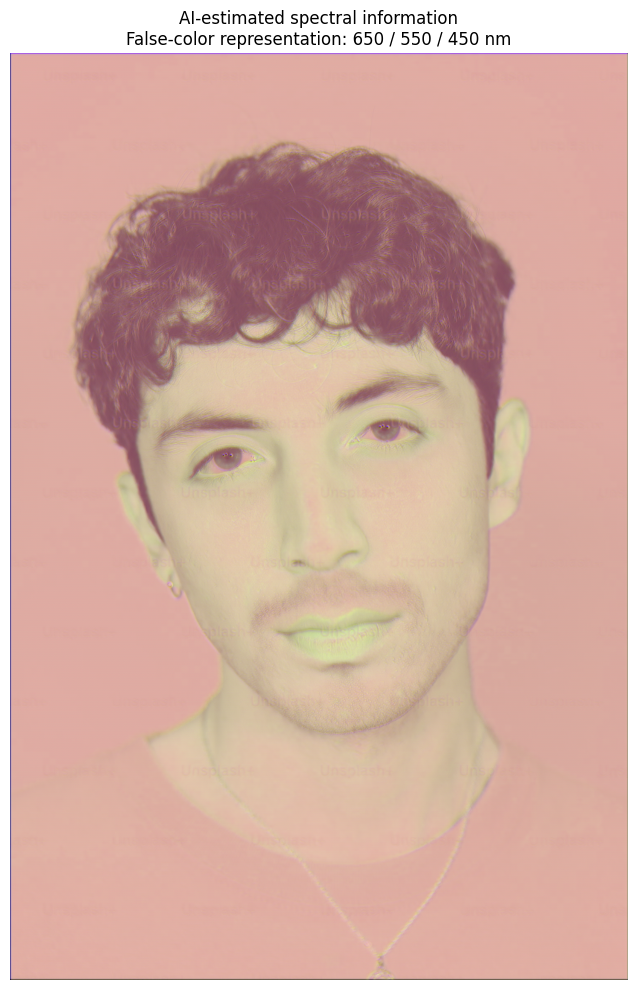

In [5]:
import matplotlib.pyplot as plt

# Create a false-color representation using:
# R = 650 nm
# G = 550 nm
# B = 450 nm
false_color = spectral_to_false_color(
    spectral_cube,
    red_nm=650,
    green_nm=550,
    blue_nm=450,
)

fig, ax = plt.subplots(figsize=(8, 10))

ax.imshow(false_color)
ax.set_title(
    "AI-estimated spectral information\n"
    "False-color representation: 650 / 550 / 450 nm"
)
ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
from pathlib import Path
from PIL import Image
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent

# Your RGB image used for the reconstruction
rgb_path = PROJECT_ROOT / "data" / "interim" / "face_resized_rgb.npy"

if rgb_path.exists():
    face_resized_rgb = np.load(rgb_path)
else:
    raise FileNotFoundError(
        f"RGB file not found: {rgb_path}\n"
        "We need to copy/save the RGB image from Colab first."
    )

print("RGB shape:", face_resized_rgb.shape)
print("RGB dtype:", face_resized_rgb.dtype)

RGB shape: (1536, 1024, 3)
RGB dtype: float32


NameError: name 'face_resized_rgb' is not defined

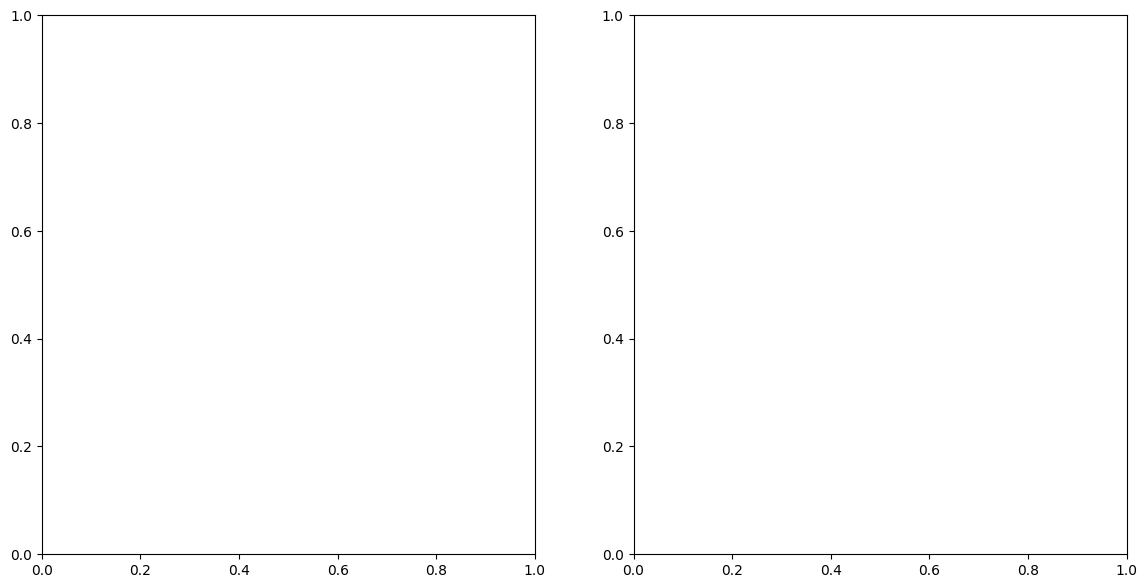

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Original RGB
axes[0].imshow(face_resized_rgb)
axes[0].set_title("Original RGB Image", fontsize=14)
axes[0].axis("off")

# AI-estimated spectral representation
axes[1].imshow(false_color)
axes[1].set_title(
    "AI-estimated spectral information\n"
    "650 / 550 / 450 nm",
    fontsize=14,
)
axes[1].axis("off")

plt.tight_layout()
plt.show()